In [41]:

# Leer datos del archivo
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/StreamingHistory_Extended.csv"
# Leer datos del archivo
spotify : pd.DataFrame = pd.read_csv(archivo)
spotify

C:\Users\49928297\AppData\Local\Temp\ipykernel_10056\246606983.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  spotify : pd.DataFrame = pd.read_csv(archivo)


,ts,username,platform,ms_played,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,is_podcast
0,2020-12-06T02:51:11Z,11145402699,"iOS 14.2 (iPhone12,3)",145610,AR,unknown,Hey Jude - Remastered 2015,The Beatles,1,spotify:track:0aym2LBJBk9DAYuHHutrIl,NaN,NaN,NaN,trackdone,fwdbtn,True,NaN,False,1607222710755,False
1,2020-12-06T02:53:31Z,11145402699,"iOS 14.2 (iPhone12,3)",138692,AR,unknown,Hacer un puente,La Franela,Hacer Un Puente,spotify:track:18Q3WTfyWX1tdS1cp42NhA,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223071185,False
2,2020-12-06T02:53:53Z,11145402699,"iOS 14.2 (iPhone12,3)",22662,AR,unknown,Happy Together - Remastered,The Turtles,All the Singles,spotify:track:2admbUc576sC6M0QeUkg2C,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223210387,False
3,2020-12-06T02:53:56Z,11145402699,"iOS 14.2 (iPhone12,3)",2716,AR,unknown,Demons,Imagine Dragons,Night Visions,spotify:track:5qaEfEh1AtSdrdrByCP7qR,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223233165,False
4,2020-12-06T02:53:57Z,11145402699,"iOS 14.2 (iPhone12,3)",116,AR,unknown,"Paint It, Black",The Rolling Stones,Aftermath,spotify:track:63T7DJ1AFDD6Bn8VzG6JE8,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223236453,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125344,2018-10-05T22:44:53Z,11145402699,"iOS 12.0 (iPhone8,1)",1365,AR,unknown,Gente Que No Sabe Lo Que Quiere,Litto Nebbia,Solo Se Trata de Vivir / Solopiano Vol. 1,spotify:track:3u8sP95YHOsYwRQfms6kgc,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779491211,False
125345,2018-10-05T22:44:54Z,11145402699,"iOS 12.0 (iPhone8,1)",1344,AR,unknown,11 Y 6,Fito Paez,Giros,spotify:track:2PkTjm1QAJCZbJ9MqC4RqA,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779492740,False
125346,2018-10-05T22:44:55Z,11145402699,"iOS 12.0 (iPhone8,1)",832,AR,unknown,Mientes,Charly García,Tango 4,spotify:track:670dXRMKr9vVtGk01dYeSr,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779494205,False
125347,2018-10-05T22:44:56Z,11145402699,"iOS 12.0 (iPhone8,1)",1194,AR,unknown,Apostar al Amor,Los Tipitos,Push,spotify:track:6PyBNCpOX5uOjKDNjNNgjq,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779495059,False


In [44]:
#1
spotify.dtypes

ts                                   object
username                              int64
platform                             object
ms_played                             int64
conn_country                         object
user_agent_decrypted                 object
master_metadata_track_name           object
master_metadata_album_artist_name    object
master_metadata_album_album_name     object
spotify_track_uri                    object
episode_name                         object
episode_show_name                    object
spotify_episode_uri                  object
reason_start                         object
reason_end                           object
shuffle                                bool
skipped                              object
offline                                bool
offline_timestamp                     int64
is_podcast                             bool
dtype: object

In [45]:
#2
print(spotify["ts"].max())
print(spotify["ts"].min())

2024-05-23T23:56:20Z
2014-06-27T18:01:15Z


In [46]:
#3
spotify["spotify_track_uri"].unique().size

11557

In [47]:
#4
spotify["ms_played"].sum()

12583875841

In [48]:
#5
artistamasescuchado =spotify.groupby(spotify["master_metadata_album_artist_name"])["ms_played"].sum().idxmax()
artistamasescuchado

'Charly García'

In [49]:
#6
spotify.groupby(spotify["spotify_track_uri"])["ms_played"].sum().idxmax()
for idx, url in spotify['spotify_track_uri'].items(): 
    if url == 'spotify:track:0wXuerDYiBnERgIpbb3JBR':
        print(spotify.loc[idx, 'master_metadata_track_name'])
        break


Redbone


In [50]:
#7
lista_artistamasecuchado =spotify[artistamasescuchado == spotify["master_metadata_album_artist_name"]]
lista_artistamasecuchado.groupby(lista_artistamasecuchado["master_metadata_track_name"])["ms_played"].sum().idxmax()

'Hablando a Tu Corazón'

In [64]:
# 1. Group by track name
# 2. Sum the columns (specifically ms_played)
# 3. Sort from highest to lowest play time
top_artist = (
    spotify.groupby("master_metadata_album_artist_name")["ms_played"]
    .sum()
    .sort_values(ascending=False)
    
)

top_artist_10=top_artist[:10]
top_artist_10


master_metadata_album_artist_name
Charly García            295324381
Luis Alberto Spinetta    276254779
Childish Gambino         259892455
Serú Girán               243400227
Daft Punk                228993913
Pink Floyd               213762858
Duran Duran              209785085
Talking Heads            204066445
Red Hot Chili Peppers    195891799
Polyphia                 173112291
Name: ms_played, dtype: int64

In [74]:
top_artist_10.values

array([295324381, 276254779, 259892455, 243400227, 228993913, 213762858,
       209785085, 204066445, 195891799, 173112291], dtype=int64)

8


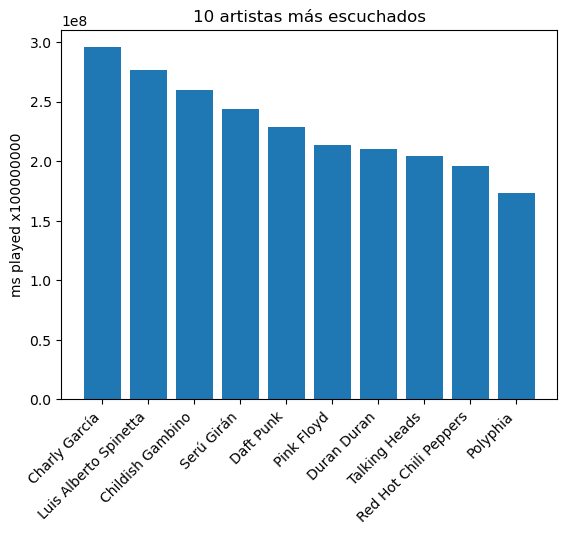

In [ ]:
#8
fig, ax = plt.subplots()

fruits = top_artist_10.index
counts = top_artist_10.values


ax.bar(fruits, counts)

ax.set_ylabel('ms played x100000000')
ax.set_title('10 artistas más escuchados')
plt.xticks(rotation=45,  ha='right')
plt.show()